In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix

import warnings
# Specifically ignore Deprecation Warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Ignore future warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wine-quality-dataset-balanced-classification/wine_data.csv


In [2]:
data = pd.read_csv('/kaggle/input/wine-quality-dataset-balanced-classification/wine_data.csv')
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


In [3]:
data.isna().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [4]:
data['quality'] = data['quality']-3

## EDA

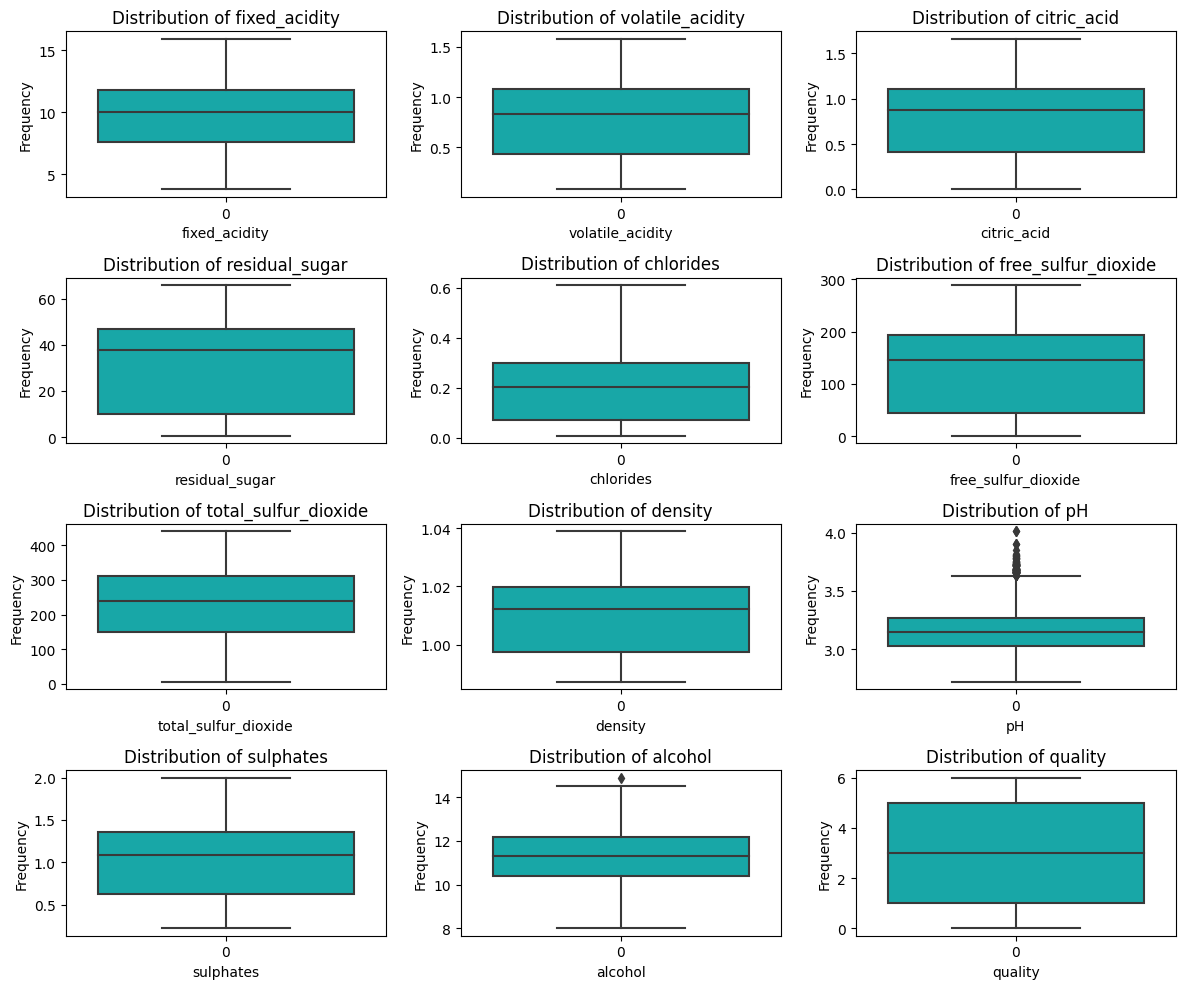

In [5]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(data.columns, start=1):
    plt.subplot(4, 3, i)
    #sns.histplot(data[col], kde=True, bins=20, color="blue")
    sns.boxplot(data[col], color="c")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

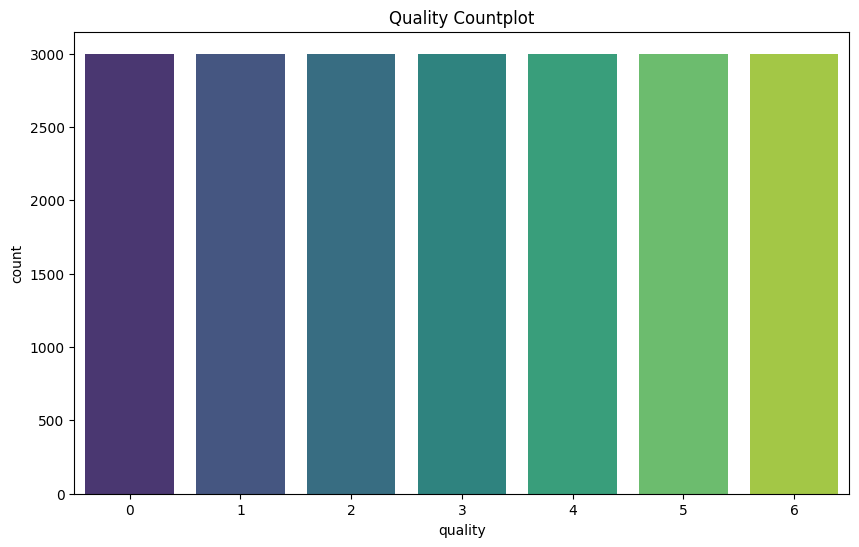

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data,x='quality',palette='viridis')
plt.title('Quality Countplot')
plt.show()

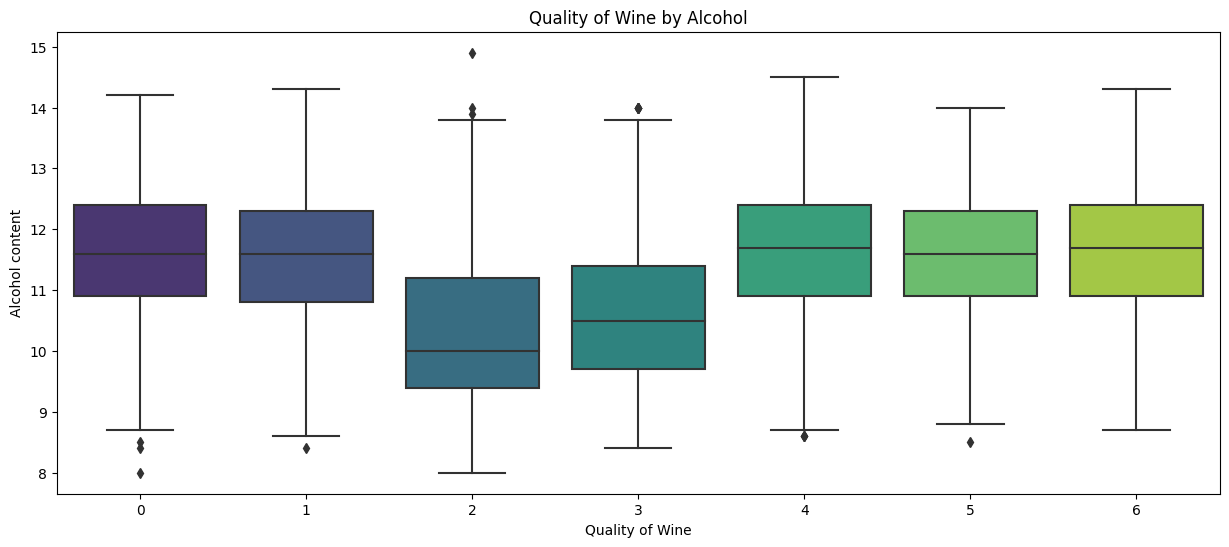

In [7]:
plt.figure(figsize=(15,6))
sns.boxplot(data=data,x='quality',y='alcohol',palette='viridis')
plt.title("Quality of Wine by Alcohol")
plt.xlabel("Quality of Wine")
plt.ylabel("Alcohol content")
plt.show()

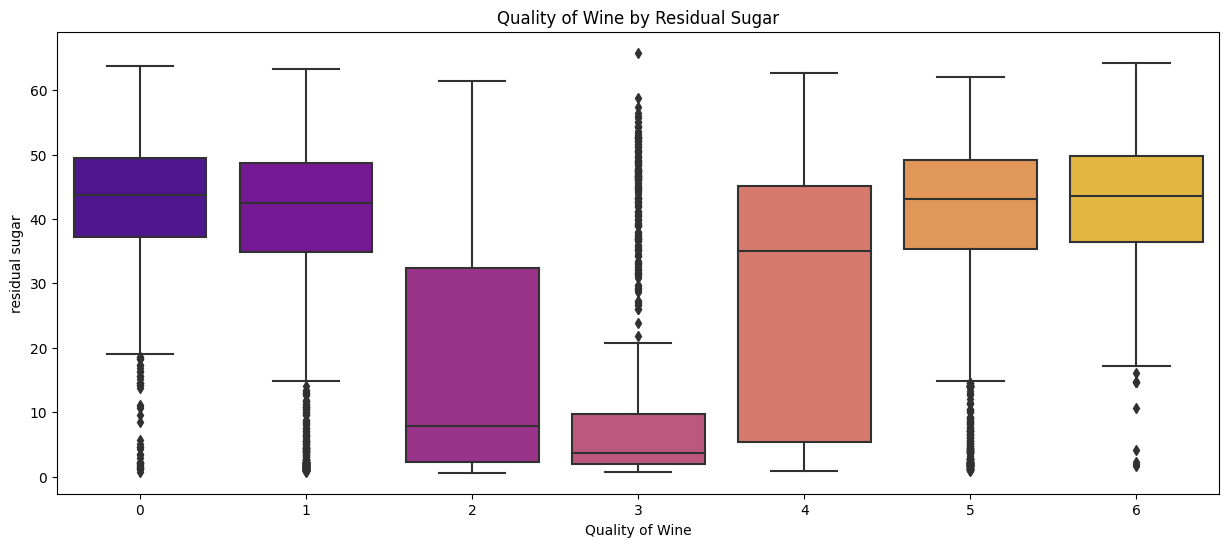

In [8]:
plt.figure(figsize=(15,6))
sns.boxplot(data=data,x='quality',y='residual_sugar',palette='plasma')
plt.title("Quality of Wine by Residual Sugar")
plt.xlabel("Quality of Wine")
plt.ylabel("residual sugar")
plt.show()

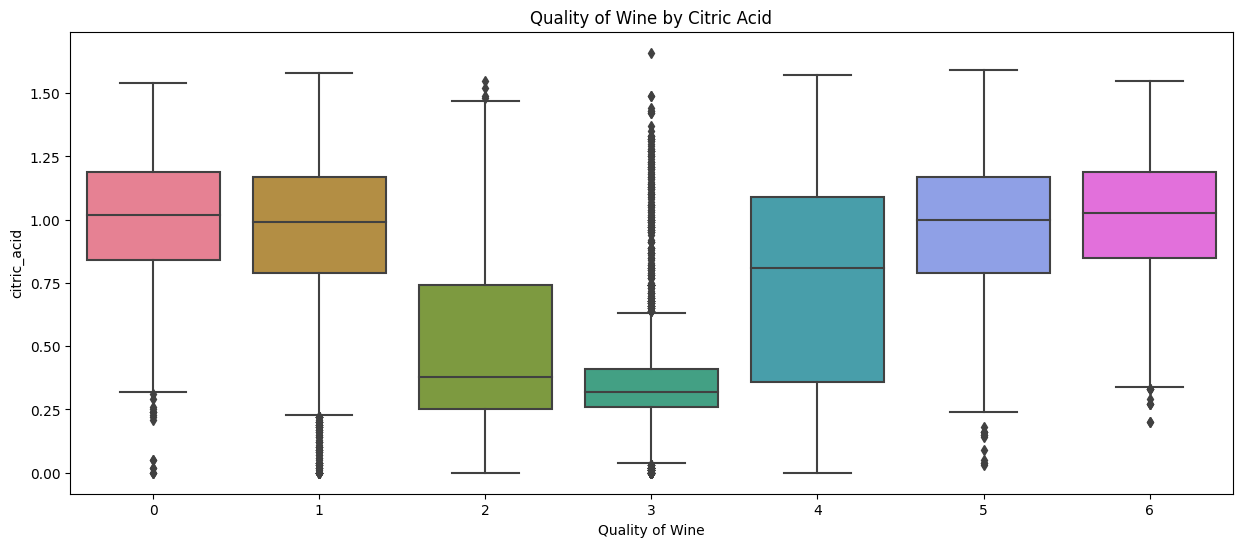

In [9]:
plt.figure(figsize=(15,6))
sns.boxplot(data=data,x='quality',y='citric_acid',palette='husl')
plt.title("Quality of Wine by Citric Acid")
plt.xlabel("Quality of Wine")
plt.ylabel("citric_acid")
plt.show()

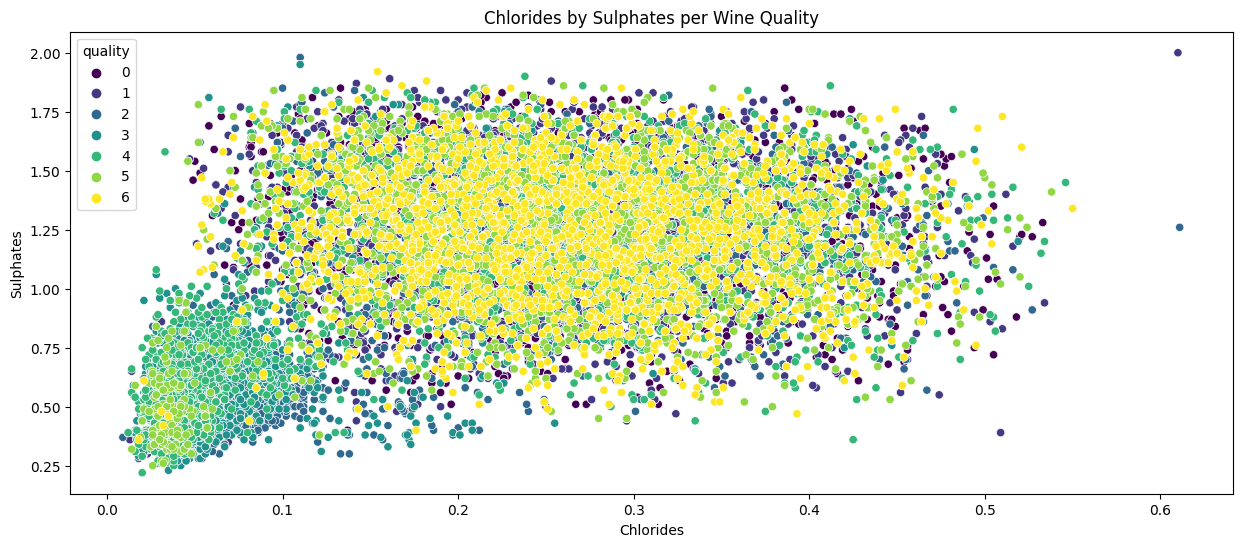

In [10]:
plt.figure(figsize=(15,6))
sns.scatterplot(data=data,x='chlorides',y='sulphates',hue='quality',palette='viridis')
plt.title("Chlorides by Sulphates per Wine Quality")
plt.xlabel("Chlorides")
plt.ylabel("Sulphates")
plt.show()

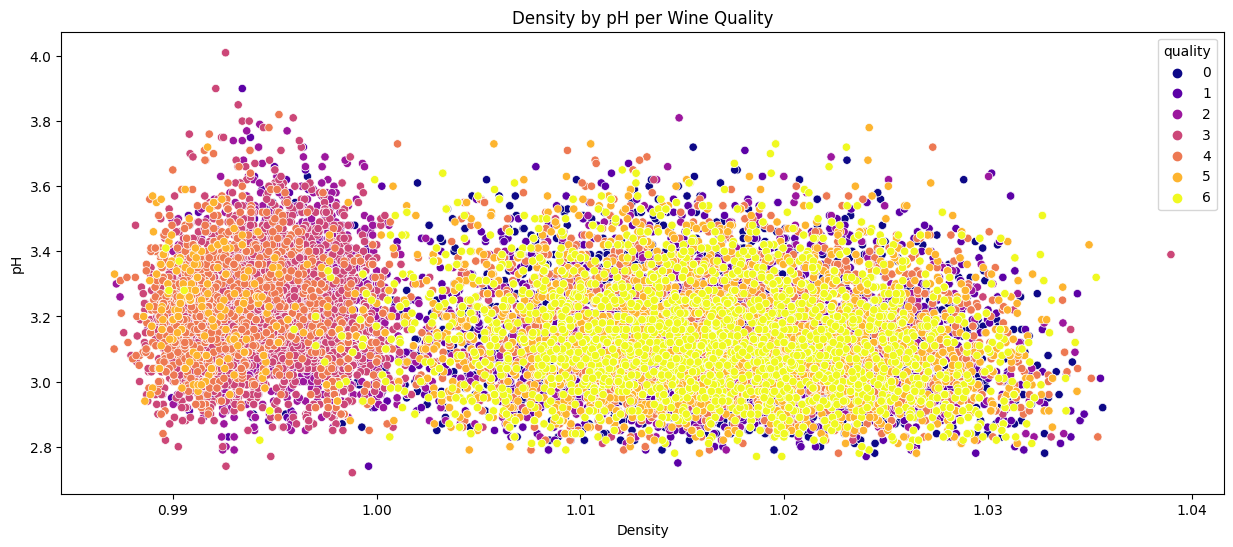

In [11]:
plt.figure(figsize=(15,6))
sns.scatterplot(data=data,x='density',y='pH',hue='quality',palette='plasma')
plt.title("Density by pH per Wine Quality")
plt.xlabel("Density")
plt.ylabel("pH")
plt.show()

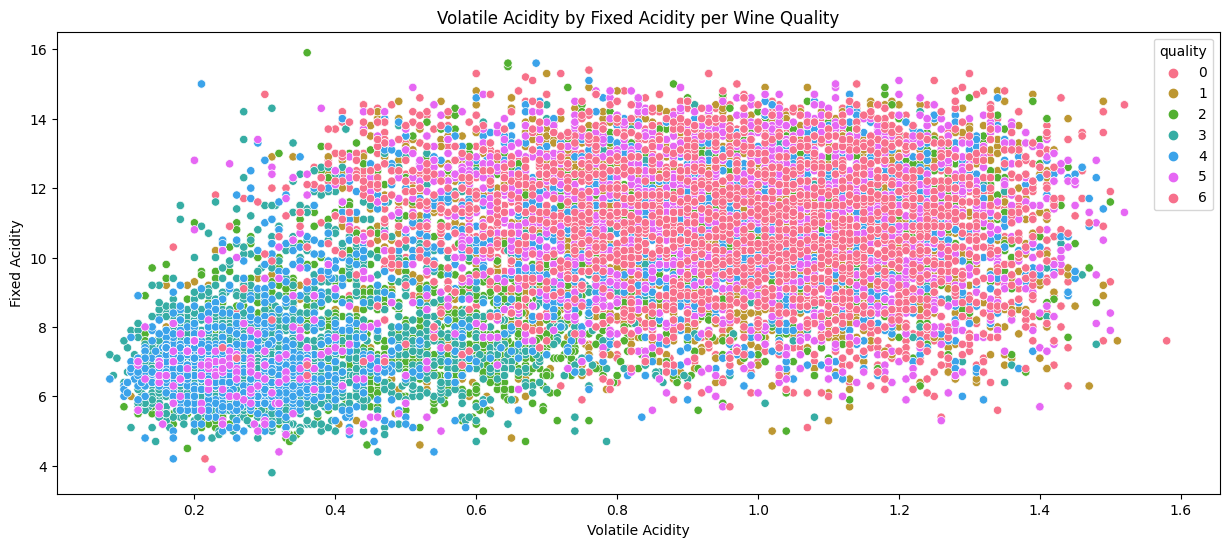

In [12]:
plt.figure(figsize=(15,6))
sns.scatterplot(data=data,x='volatile_acidity',y='fixed_acidity',hue='quality',palette='husl')
plt.title("Volatile Acidity by Fixed Acidity per Wine Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Fixed Acidity")
plt.show()

## Modelling

In [13]:
X = data.drop('quality',axis=1)
y = data['quality']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape)

(16800, 11) (4200, 11)


In [14]:
def model_metrics(y_test,y_pred,model,name):
    
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix for {name} Classifier')
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

In [15]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=6, random_state=1)

## Decision Tree

Model accuracy score Decision Tree: 0.5950
CV mean Accuracy Decision Tree: 0.5698015873015873


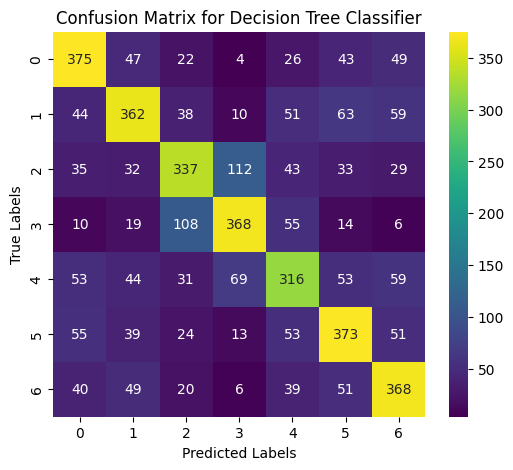

In [16]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_dt_train = dt.predict(X_train)
print('Model accuracy score Decision Tree: {0:0.4f}'. format(accuracy_score(y_test, y_pred_dt)))

n_scores_dt = cross_val_score(dt, X_train, y_train, scoring='accuracy', cv=cv)
print(f'CV mean Accuracy Decision Tree: {n_scores_dt.mean()}')

model_metrics(y_test,y_pred=y_pred_dt,model=dt,name='Decision Tree')

## Random Forest

Model accuracy score RF: 0.6100
Cross Validation mean Accuracy RF 0.5984623015873016


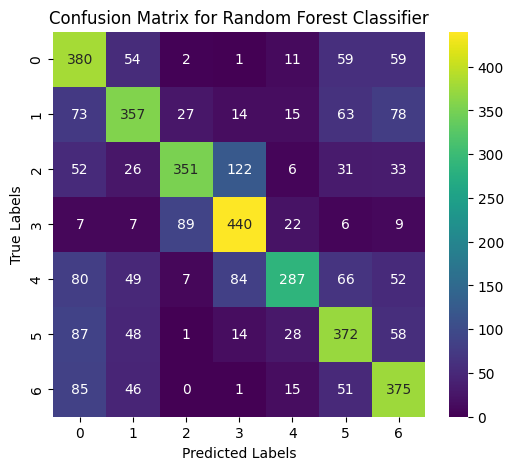

In [17]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
print('Model accuracy score RF: {0:0.4f}'. format(accuracy_score(y_test, y_pred_rf)))

n_scores_rf = cross_val_score(rf, X_train, y_train, scoring='accuracy', cv=cv)
print(f'Cross Validation mean Accuracy RF {n_scores_rf.mean()}')

model_metrics(y_test,y_pred=y_pred_rf,model=rf,name = 'Random Forest')

## XGBoost

Model accuracy score XGB: 0.6169
Cross Validation mean Accuracy XGB 0.5970833333333334


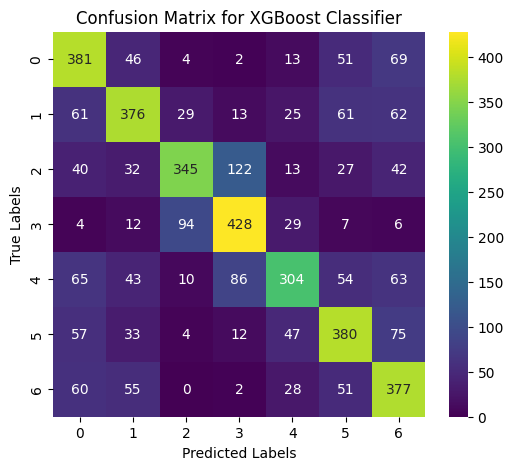

In [18]:
xgb = XGBClassifier(objective='multi:softmax',num_class=7,max_depth= 10, eta= 0.1, n_estimators= 200, subsample= 1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('Model accuracy score XGB: {0:0.4f}'. format(accuracy_score(y_test, y_pred_xgb)))

n_scores_xgb = cross_val_score(xgb, X_train, y_train, scoring='accuracy', cv=cv)
print(f'Cross Validation mean Accuracy XGB {n_scores_xgb.mean()}')
model_metrics(y_test,y_pred=y_pred_xgb,model=xgb,name = 'XGBoost')